# CUAD Class Imbalance Exploration



# Imbalance EDA Analysis
Goal: Evaluate how unevenly the 41 CUAD clause categories are represented and identify what that may mean for modeling.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:

train_df = pd.read_pickle("../data/cuad/dataframes/train.pkl")
test_df = pd.read_pickle("../data/cuad/dataframes/test.pkl")
full_df = pd.read_pickle("../data/cuad/dataframes/full.pkl")

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
print("Full shape:", full_df.shape)

Train shape: (16728, 10)
Test shape: (4182, 10)
Full shape: (20910, 10)


In [6]:
print(full_df.columns.tolist())
display(full_df.head())

['contract_title', 'category', 'split', 'question', 'qa_id', 'is_impossible', 'num_answers', 'answer_texts', 'answer_starts', 'context_length']


,contract_title,category,split,question,qa_id,is_impossible,num_answers,answer_texts,answer_starts,context_length
0,2ThemartComInc_19990826_10-12G_EX-10.10_670028...,Affiliate License-Licensee,full,Highlight the parts (if any) of this contract ...,2ThemartComInc_19990826_10-12G_EX-10.10_670028...,True,0,[],[],29454
1,2ThemartComInc_19990826_10-12G_EX-10.10_670028...,Affiliate License-Licensor,full,Highlight the parts (if any) of this contract ...,2ThemartComInc_19990826_10-12G_EX-10.10_670028...,True,0,[],[],29454
2,2ThemartComInc_19990826_10-12G_EX-10.10_670028...,Agreement Date,full,Highlight the parts (if any) of this contract ...,2ThemartComInc_19990826_10-12G_EX-10.10_670028...,False,1,"[June 21, 1999]",[114],29454
3,2ThemartComInc_19990826_10-12G_EX-10.10_670028...,Anti-Assignment,full,Highlight the parts (if any) of this contract ...,2ThemartComInc_19990826_10-12G_EX-10.10_670028...,False,2,[All rights (under any applicable intellectual...,"[12261, 12412]",29454
4,2ThemartComInc_19990826_10-12G_EX-10.10_670028...,Audit Rights,full,Highlight the parts (if any) of this contract ...,2ThemartComInc_19990826_10-12G_EX-10.10_670028...,False,3,[Such inspection shall be at 2TheMart's expens...,"[8958, 8593, 8701]",29454


In [7]:
print("Rows:", len(full_df))
print("Unique contracts:", full_df["contract_title"].nunique())
print("Unique categories:", full_df["category"].nunique())

print("\nSplit values:")
print(full_df["split"].value_counts())

Rows: 20910
Unique contracts: 510
Unique categories: 41

Split values:
split
full    20910
Name: count, dtype: int64


In [8]:
check = (
    (full_df["is_impossible"] == False)
    ==
    (full_df["num_answers"] > 0)
)

print("Rows where positive status matches num_answers:", check.sum())
print("Rows where they disagree:", (~check).sum())

Rows where positive status matches num_answers: 20910
Rows where they disagree: 0


In [ ]:
# This table is showing within-label imbalance because each row compares positive vs negative
#  contracts for the same category.
imbalance_df = (
    full_df
    .groupby("category")
    .agg(
        Positive_Contracts=("is_impossible", lambda x: (~x).sum()),
        Negative_Contracts=("is_impossible", "sum")
    )
    .reset_index()
)

imbalance_df["Percent_Positive"] = (
    imbalance_df["Positive_Contracts"]
    /
    (imbalance_df["Positive_Contracts"] + imbalance_df["Negative_Contracts"])
    * 100
).round(1)

imbalance_df = imbalance_df.sort_values(
    "Positive_Contracts",
    ascending=False
)

imbalance_df

,category,Positive_Contracts,Negative_Contracts,Percent_Positive
9,Document Name,510,0,100.0
28,Parties,509,1,99.8
2,Agreement Date,470,40,92.2
13,Governing Law,437,73,85.7
12,Expiration Date,413,97,81.0
10,Effective Date,390,120,76.5
3,Anti-Assignment,374,136,73.3
5,Cap On Liability,275,235,53.9
18,License Grant,255,255,50.0
4,Audit Rights,214,296,42.0


### Observation — Overall label frequency

The percentage of contracts containing each label varies substantially.

Examples:
- Document Name: 100%
- Parties: 99.8%
- Cap On Liability: 53.9%
- Change Of Control: 23.7%
- Source Code Escrow: 2.5%

This shows strong between-label imbalance: some CUAD categories appear in nearly every contract, while others appear in very few.

In [10]:
median_positive = imbalance_df["Positive_Contracts"].median()

most_common = imbalance_df["Positive_Contracts"].max()
least_common = imbalance_df["Positive_Contracts"].min()

imbalance_ratio = most_common / least_common

print("Median positive contracts:", median_positive)
print("Most common positive count:", most_common)
print("Least common positive count:", least_common)
print("Overall positive-frequency imbalance ratio:", round(imbalance_ratio, 2), ": 1")

Median positive contracts: 119.0
Most common positive count: 510
Least common positive count: 13
Overall positive-frequency imbalance ratio: 39.23 : 1


### Observation — Between-Label Imbalance

- The median category appears in 119 of 510 contracts, or about 23% of the dataset.

- This means that if all 41 labels are sorted by frequency, the category in the middle is still absent from most contracts.

- The most common label has 510 positive examples, while the rarest has only 13.

- Overall positive-frequency imbalance ratio of  **39.23:1**.

- The most represented label has about 39 times as many positive contract examples as the least represented label.

In [11]:
imbalance_df["Negative_to_Positive_Ratio"] = (
    imbalance_df["Negative_Contracts"]
    / imbalance_df["Positive_Contracts"]
).round(2)

imbalance_df[
    [
        "category",
        "Positive_Contracts",
        "Negative_Contracts",
        "Percent_Positive",
        "Negative_to_Positive_Ratio"
    ]
].sort_values(
    "Negative_to_Positive_Ratio",
    ascending=False
)

,category,Positive_Contracts,Negative_Contracts,Percent_Positive,Negative_to_Positive_Ratio
34,Source Code Escrow,13,497,2.5,38.23
30,Price Restrictions,15,495,2.9,33.00
38,Unlimited/All-You-Can-Eat-License,17,493,3.3,29.00
1,Affiliate License-Licensor,23,487,4.5,21.17
21,Most Favored Nation,28,482,5.5,17.21
36,Third Party Beneficiary,32,478,6.3,14.94
22,No-Solicit Of Customers,34,476,6.7,14.00
25,Non-Disparagement,38,472,7.5,12.42
17,Joint Ip Ownership,46,464,9.0,10.09
23,No-Solicit Of Employees,59,451,11.6,7.64


### Observation — Within-Label Imbalance

Class imbalance also occurs within individual categories.

Example:

`Source Code Escrow`
- Positive: 13
- Negative: 497
- Positive prevalence: 2.5%
- About 38 negative contracts for every 1 positive contract

By contrast:

`License Grant`
- Positive: 255
- Negative: 255
- Positive prevalence: 50%

`License Grant` is almost perfectly balanced, while `Source Code Escrow` is extremely skewed toward the negative class.

This means some CUAD labels create much harder binary classification problems than others.

In [12]:
def rarity_group(percent):
    if percent > 50:
        return "Very Common"
    elif percent >= 20:
        return "Moderate"
    elif percent >= 5:
        return "Rare"
    else:
        return "Very Rare"

imbalance_df["Rarity_Group"] = (
    imbalance_df["Percent_Positive"].apply(rarity_group)
)

rarity_counts = imbalance_df["Rarity_Group"].value_counts()

rarity_counts

Rarity_Group
Moderate       15
Rare           14
Very Common     8
Very Rare       4
Name: count, dtype: int64

### Analysis Frequency Groups

To summarize positive prevalence, categories were grouped using the following analysis-defined thresholds:

- **Very Common:** >50% of contracts positive
- **Moderate:** 20–50%
- **Rare:** 5–20%
- **Very Rare:** <5%

These are not official CUAD classifications. They are analysis buckets used to make the class distribution easier to interpret.

In [13]:
for group in ["Very Common", "Moderate", "Rare", "Very Rare"]:
    print(f"\n{group}")
    
    group_df = imbalance_df[
        imbalance_df["Rarity_Group"] == group
    ][["category", "Positive_Contracts", "Percent_Positive"]]
    
    display(group_df)


Very Common


,category,Positive_Contracts,Percent_Positive
9,Document Name,510,100.0
28,Parties,509,99.8
2,Agreement Date,470,92.2
13,Governing Law,437,85.7
12,Expiration Date,413,81.0
10,Effective Date,390,76.5
3,Anti-Assignment,374,73.3
5,Cap On Liability,275,53.9



Moderate


,category,Positive_Contracts,Percent_Positive
18,License Grant,255,50.0
4,Audit Rights,214,42.0
35,Termination For Convenience,183,35.9
29,Post-Termination Services,182,35.7
11,Exclusivity,180,35.3
31,Renewal Term,176,34.5
32,Revenue/Profit Sharing,166,32.5
14,Insurance,166,32.5
20,Minimum Commitment,165,32.4
26,Non-Transferable License,138,27.1



Rare


,category,Positive_Contracts,Percent_Positive
8,Covenant Not To Sue,100,19.6
33,Rofr/Rofo/Rofn,85,16.7
39,Volume Restriction,82,16.1
7,Competitive Restriction Exception,76,14.9
40,Warranty Duration,75,14.7
16,Irrevocable Or Perpetual License,70,13.7
19,Liquidated Damages,61,12.0
23,No-Solicit Of Employees,59,11.6
0,Affiliate License-Licensee,59,11.6
17,Joint Ip Ownership,46,9.0



Very Rare


,category,Positive_Contracts,Percent_Positive
1,Affiliate License-Licensor,23,4.5
38,Unlimited/All-You-Can-Eat-License,17,3.3
30,Price Restrictions,15,2.9
34,Source Code Escrow,13,2.5


In [14]:
print("Very Common:",
      (imbalance_df["Rarity_Group"] == "Very Common").sum())

print("Moderate:",
      (imbalance_df["Rarity_Group"] == "Moderate").sum())

print("Rare:",
      (imbalance_df["Rarity_Group"] == "Rare").sum())

print("Very Rare:",
      (imbalance_df["Rarity_Group"] == "Very Rare").sum())

Very Common: 8
Moderate: 15
Rare: 14
Very Rare: 4


### Observation — Distribution Across Frequency Groups

Using these analysis thresholds:

- 8 labels are Very Common
- 15 labels are Moderate
- 14 labels are Rare
- 4 labels are Very Rare

This means **18 of the 41 CUAD categories are classified as Rare or Very Rare** in this analysis.

A substantial portion of the label space therefore has relatively limited positive representation.

In [16]:
very_rare_df = imbalance_df[
    imbalance_df["Rarity_Group"] == "Very Rare"
][
    [
        "category",
        "Positive_Contracts",
        "Negative_Contracts",
        "Percent_Positive",
        "Negative_to_Positive_Ratio"
    ]
].sort_values("Positive_Contracts")

very_rare_df

,category,Positive_Contracts,Negative_Contracts,Percent_Positive,Negative_to_Positive_Ratio
34,Source Code Escrow,13,497,2.5,38.23
30,Price Restrictions,15,495,2.9,33.00
38,Unlimited/All-You-Can-Eat-License,17,493,3.3,29.00
1,Affiliate License-Licensor,23,487,4.5,21.17


### Observation — Most Severely Imbalanced Categories

The four Very Rare categories are:

- `Affiliate License-Licensor`: 23 positive / 487 negative
- `Unlimited/All-You-Can-Eat-License`: 17 / 493
- `Price Restrictions`: 15 / 495
- `Source Code Escrow`: 13 / 497

These labels may be especially difficult for a model to learn because very few positive examples are available compared with the number of negatives.

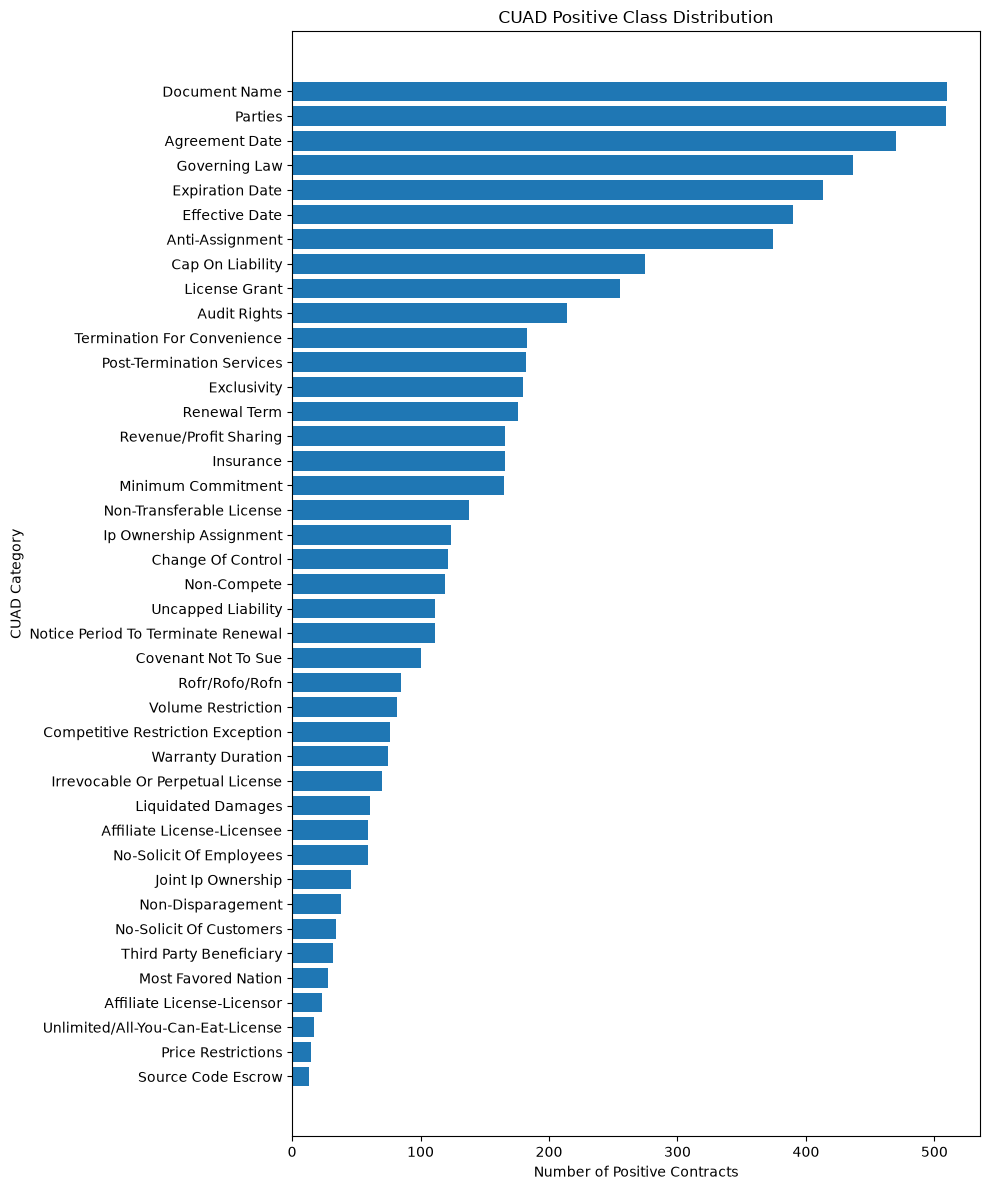

In [17]:
plot_df = imbalance_df.sort_values(
    "Positive_Contracts",
    ascending=True
)

plt.figure(figsize=(10, 12))

plt.barh(
    plot_df["category"],
    plot_df["Positive_Contracts"]
)

plt.xlabel("Number of Positive Contracts")
plt.ylabel("CUAD Category")
plt.title("CUAD Positive Class Distribution")
plt.tight_layout()

plt.show()

# Summarized EDA Observations

percent of contract containing each label —
- Document Name = 100%
- Parties = 99.8%
- Cap On Liability = 53.9%
- Change Of Control = 23.7%
- Source Code Escrow = 2.5%

median positive count — 119/510 contracts
- if you sort all 41 labels by how often they appear, the label in the middle occurs in 119 contracts — 23% ; typical CUAD label is not present in most contracts.
- 39.23% imbalance ratio : most common positive count ÷ least common positive count

Negative Contracts: class imbalance exists not only between labels, but also inside each label
Between-class imbalance: one label has 400 positives while another has 20
Within-class imbalance: for one particular label, positive examples are vastly outnumbered by negatives.

Rarity groups (within class imbalance) —
(ex. Source Code Escrow Positive: 13 Negative: 497 Positive rate: 2.5%)

Very Common > 50% - 8
Moderate = 20–50% - 15
Rare = 5–20% - 14
Very Rare < 5% - 4

Very rare groups:
Affiliate License-Licensor — 23 positives / 487 negatives
Unlimited/All-You-Can-Eat-License — 17 / 493
Price Restrictions — 15 / 495
Source Code Escrow — 13 / 497



# Train/Test Distribution Analysis

Goal: compare the distribution of the 41 CUAD categories between the training and test sets.

In [4]:
print("Train rows:", len(train_df))
print("Test rows:", len(test_df))

print("Train contracts:", train_df["contract_title"].nunique())
print("Test contracts:", test_df["contract_title"].nunique())

print("Train categories:", train_df["category"].nunique())
print("Test categories:", test_df["category"].nunique())

Train rows: 16728
Test rows: 4182
Train contracts: 408
Test contracts: 102
Train categories: 41
Test categories: 41


### Observation — Split Structure

- The dataset uses 408 training contracts and 102 test contracts, an approximately 80/20 split.
- All 41 CUAD categories appear as columns/label entries in both splits.
- This confirms the train and test data preserve the full set of CUAD categories.

In [6]:
# Helper function that takes in a dataframe and returns a summary of the
#  positive vs negative counts for each category.
def summarize_split(df):
    summary = (
        df
        .groupby("category")
        .agg(
            Positive=("is_impossible", lambda x: (~x).sum()),
            Negative=("is_impossible", "sum")
        )
        .reset_index()
    )

    summary["Total"] = (
        summary["Positive"] + summary["Negative"]
    )

    summary["Percent_Positive"] = (
        summary["Positive"] / summary["Total"] * 100
    ).round(1)

    return summary

In [8]:
#Calculating train v test distributions
train_summary = summarize_split(train_df)
test_summary = summarize_split(test_df)

print("TRAIN:")
display(train_summary)

print("TEST:")
display(test_summary)

TRAIN:


,category,Positive,Negative,Total,Percent_Positive
0,Affiliate License-Licensee,47,361,408,11.5
1,Affiliate License-Licensor,17,391,408,4.2
2,Agreement Date,377,31,408,92.4
3,Anti-Assignment,302,106,408,74.0
4,Audit Rights,176,232,408,43.1
5,Cap On Liability,231,177,408,56.6
6,Change Of Control,95,313,408,23.3
7,Competitive Restriction Exception,60,348,408,14.7
8,Covenant Not To Sue,76,332,408,18.6
9,Document Name,408,0,408,100.0


TEST:


,category,Positive,Negative,Total,Percent_Positive
0,Affiliate License-Licensee,12,90,102,11.8
1,Affiliate License-Licensor,6,96,102,5.9
2,Agreement Date,93,9,102,91.2
3,Anti-Assignment,72,30,102,70.6
4,Audit Rights,38,64,102,37.3
5,Cap On Liability,44,58,102,43.1
6,Change Of Control,26,76,102,25.5
7,Competitive Restriction Exception,16,86,102,15.7
8,Covenant Not To Sue,24,78,102,23.5
9,Document Name,102,0,102,100.0


In [9]:
split_comparison = train_summary.merge(
    test_summary,
    on="category",
    suffixes=("_Train", "_Test")
)

split_comparison = split_comparison[
    [
        "category",
        "Positive_Train",
        "Negative_Train",
        "Percent_Positive_Train",
        "Positive_Test",
        "Negative_Test",
        "Percent_Positive_Test"
    ]
]

split_comparison = split_comparison.sort_values(
    "Positive_Train",
    ascending=False
)

split_comparison

,category,Positive_Train,Negative_Train,Percent_Positive_Train,Positive_Test,Negative_Test,Percent_Positive_Test
9,Document Name,408,0,100.0,102,0,100.0
28,Parties,407,1,99.8,102,0,100.0
2,Agreement Date,377,31,92.4,93,9,91.2
13,Governing Law,354,54,86.8,83,19,81.4
12,Expiration Date,335,73,82.1,78,24,76.5
10,Effective Date,320,88,78.4,70,32,68.6
3,Anti-Assignment,302,106,74.0,72,30,70.6
5,Cap On Liability,231,177,56.6,44,58,43.1
18,License Grant,205,203,50.2,50,52,49.0
4,Audit Rights,176,232,43.1,38,64,37.3


### Observation — Train/Test Label Distribution

- The same broad class-imbalance pattern seen in the full dataset is also present in both the training and test sets.
- Common categories remain common in both splits, while rare categories remain sparse.
- For example, `Document Name` is positive in 100% of both splits, while `Source Code Escrow` has only 12 positive training examples and 1 positive test example.
- This means some rare labels have very limited data available both for learning and for evaluation.

In [10]:
low_train = split_comparison[
    split_comparison["Positive_Train"] < 20
].sort_values("Positive_Train")

low_train

,category,Positive_Train,Negative_Train,Percent_Positive_Train,Positive_Test,Negative_Test,Percent_Positive_Test
34,Source Code Escrow,12,396,2.9,1,101,1.0
38,Unlimited/All-You-Can-Eat-License,14,394,3.4,3,99,2.9
30,Price Restrictions,15,393,3.7,0,102,0.0
1,Affiliate License-Licensor,17,391,4.2,6,96,5.9


### Observation — Very Low Training Support

Four categories have fewer than 20 positive training examples:

- `Source Code Escrow`: 12
- `Unlimited/All-You-Can-Eat-License`: 14
- `Price Restrictions`: 15
- `Affiliate License-Licensor`: 17

These categories may be especially difficult for a model to learn because the model sees very few positive examples compared with hundreds of negative examples.

In [11]:
low_test = split_comparison[
    split_comparison["Positive_Test"] < 5
].sort_values("Positive_Test")

low_test

,category,Positive_Train,Negative_Train,Percent_Positive_Train,Positive_Test,Negative_Test,Percent_Positive_Test
30,Price Restrictions,15,393,3.7,0,102,0.0
34,Source Code Escrow,12,396,2.9,1,101,1.0
21,Most Favored Nation,25,383,6.1,3,99,2.9
38,Unlimited/All-You-Can-Eat-License,14,394,3.4,3,99,2.9


### Observation — Very Low Test Support

Several categories have fewer than five positive examples in the test set:

- `Price Restrictions`: 0
- `Source Code Escrow`: 1
- `Most Favored Nation`: 3
- `Unlimited/All-You-Can-Eat-License`: 3

Metrics for these categories will be difficult or unstable to interpret.

For example, if a category has only one positive test example, recall can only be either 0% or 100% depending on whether that single example is detected.

In [12]:
zero_train = split_comparison[
    split_comparison["Positive_Train"] == 0
]

zero_test = split_comparison[
    split_comparison["Positive_Test"] == 0
]

print("Categories with ZERO train positives:")
display(zero_train)

print("Categories with ZERO test positives:")
display(zero_test)

Categories with ZERO train positives:


,category,Positive_Train,Negative_Train,Percent_Positive_Train,Positive_Test,Negative_Test,Percent_Positive_Test


Categories with ZERO test positives:


,category,Positive_Train,Negative_Train,Percent_Positive_Train,Positive_Test,Negative_Test,Percent_Positive_Test
30,Price Restrictions,15,393,3.7,0,102,0.0


### Observation — Zero-Positive Categories

- Every category has at least one positive example in the training set.
- `Price Restrictions` has no positive examples in the test set.

This means the model can at least see positive examples for every category during training.

However, `Price Restrictions` cannot be meaningfully evaluated for positive-class recall or F1 on this test split because there are no positive test examples.

In [13]:
split_comparison["Percent_Difference"] = (
    split_comparison["Percent_Positive_Train"]
    -
    split_comparison["Percent_Positive_Test"]
).abs().round(1)

split_comparison[
    [
        "category",
        "Percent_Positive_Train",
        "Percent_Positive_Test",
        "Percent_Difference"
    ]
].sort_values(
    "Percent_Difference",
    ascending=False
)

,category,Percent_Positive_Train,Percent_Positive_Test,Percent_Difference
5,Cap On Liability,56.6,43.1,13.5
37,Uncapped Liability,24.0,12.7,11.3
31,Renewal Term,36.8,25.5,11.3
10,Effective Date,78.4,68.6,9.8
35,Termination For Convenience,37.7,28.4,9.3
29,Post-Termination Services,37.5,28.4,9.1
27,Notice Period To Terminate Renewal,23.3,15.7,7.6
26,Non-Transferable License,28.4,21.6,6.8
40,Warranty Duration,15.9,9.8,6.1
4,Audit Rights,43.1,37.3,5.8


### Observation — Distribution Differences Between Train and Test

Some categories have noticeably different positive prevalence between the training and test sets.

The largest differences include:

- `Cap On Liability`: 56.6% train vs 43.1% test
- `Renewal Term`: 36.8% vs 25.5%
- `Uncapped Liability`: 24.0% vs 12.7%
- `Effective Date`: 78.4% vs 68.6%

These differences mean that the test set is not an exact miniature of the training distribution for every category.

This does not automatically mean the split is invalid, but it is important to consider when interpreting model performance.

In [14]:
large_split_differences = split_comparison[
    split_comparison["Percent_Difference"] >= 5
].sort_values(
    "Percent_Difference",
    ascending=False
)

large_split_differences

,category,Positive_Train,Negative_Train,Percent_Positive_Train,Positive_Test,Negative_Test,Percent_Positive_Test,Percent_Difference
5,Cap On Liability,231,177,56.6,44,58,43.1,13.5
31,Renewal Term,150,258,36.8,26,76,25.5,11.3
37,Uncapped Liability,98,310,24.0,13,89,12.7,11.3
10,Effective Date,320,88,78.4,70,32,68.6,9.8
35,Termination For Convenience,154,254,37.7,29,73,28.4,9.3
29,Post-Termination Services,153,255,37.5,29,73,28.4,9.1
27,Notice Period To Terminate Renewal,95,313,23.3,16,86,15.7,7.6
26,Non-Transferable License,116,292,28.4,22,80,21.6,6.8
40,Warranty Duration,65,343,15.9,10,92,9.8,6.1
4,Audit Rights,176,232,43.1,38,64,37.3,5.8


In [15]:
split_comparison["Total_Positive"] = (
    split_comparison["Positive_Train"]
    +
    split_comparison["Positive_Test"]
)

split_comparison["Percent_Positive_in_Test"] = (
    split_comparison["Positive_Test"]
    /
    split_comparison["Total_Positive"]
    * 100
).round(1)

split_comparison[
    [
        "category",
        "Positive_Train",
        "Positive_Test",
        "Total_Positive",
        "Percent_Positive_in_Test"
    ]
].sort_values("Total_Positive")

,category,Positive_Train,Positive_Test,Total_Positive,Percent_Positive_in_Test
34,Source Code Escrow,12,1,13,7.7
30,Price Restrictions,15,0,15,0.0
38,Unlimited/All-You-Can-Eat-License,14,3,17,17.6
1,Affiliate License-Licensor,17,6,23,26.1
21,Most Favored Nation,25,3,28,10.7
36,Third Party Beneficiary,26,6,32,18.8
22,No-Solicit Of Customers,27,7,34,20.6
25,Non-Disparagement,31,7,38,18.4
17,Joint Ip Ownership,39,7,46,15.2
0,Affiliate License-Licensee,47,12,59,20.3


### Observation — Share of Positive Examples in Test

Because the overall dataset is split approximately 80/20, many categories have around 20% of their positive examples in the test set.

However, rare categories vary much more because the total number of positives is so small.

For example:

- `Source Code Escrow`: only 1 of 13 positives is in test
- `Price Restrictions`: 0 of 15 positives are in test
- `Affiliate License-Licensor`: 6 of 23 positives are in test

This shows that percentage-based split differences can become unstable when a category has very few total positive examples.

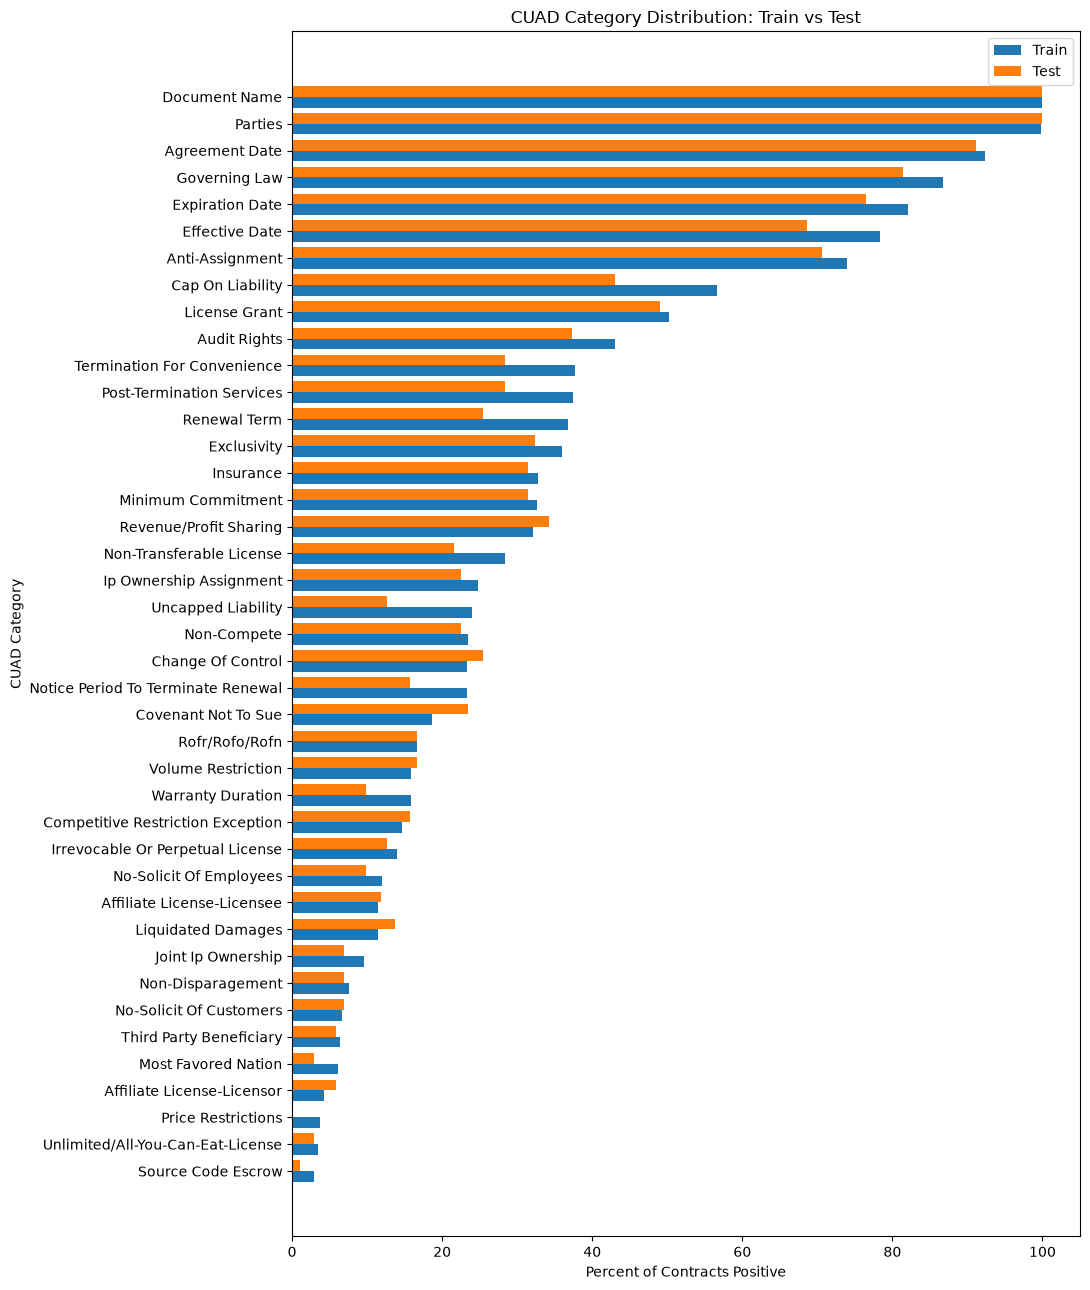

In [16]:
plot_df = split_comparison.sort_values(
    "Percent_Positive_Train",
    ascending=True
)

y = np.arange(len(plot_df))

plt.figure(figsize=(11, 13))

plt.barh(
    y - 0.2,
    plot_df["Percent_Positive_Train"],
    height=0.4,
    label="Train"
)

plt.barh(
    y + 0.2,
    plot_df["Percent_Positive_Test"],
    height=0.4,
    label="Test"
)

plt.yticks(y, plot_df["category"])

plt.xlabel("Percent of Contracts Positive")
plt.ylabel("CUAD Category")
plt.title("CUAD Category Distribution: Train vs Test")

plt.legend()
plt.tight_layout()
plt.show()

In [17]:
concern_df = split_comparison[
    (split_comparison["Positive_Train"] < 20)
    |
    (split_comparison["Positive_Test"] < 5)
    |
    (split_comparison["Percent_Difference"] >= 5)
].copy()

concern_df[
    [
        "category",
        "Positive_Train",
        "Positive_Test",
        "Percent_Positive_Train",
        "Percent_Positive_Test",
        "Percent_Difference"
    ]
].sort_values(
    ["Positive_Train", "Positive_Test"]
)

,category,Positive_Train,Positive_Test,Percent_Positive_Train,Percent_Positive_Test,Percent_Difference
34,Source Code Escrow,12,1,2.9,1.0,1.9
38,Unlimited/All-You-Can-Eat-License,14,3,3.4,2.9,0.5
30,Price Restrictions,15,0,3.7,0.0,3.7
1,Affiliate License-Licensor,17,6,4.2,5.9,1.7
21,Most Favored Nation,25,3,6.1,2.9,3.2
40,Warranty Duration,65,10,15.9,9.8,6.1
27,Notice Period To Terminate Renewal,95,16,23.3,15.7,7.6
37,Uncapped Liability,98,13,24.0,12.7,11.3
26,Non-Transferable License,116,22,28.4,21.6,6.8
31,Renewal Term,150,26,36.8,25.5,11.3


### Observation — Categories Requiring Extra Attention

This table flags categories that have at least one of the following:

- fewer than 20 positive training examples,
- fewer than 5 positive test examples,
- or a train/test prevalence difference of at least 5 percentage points.

The flagged categories fall into two different types of concern:

1. **Sparse categories**, where there may not be enough positive examples to train or evaluate reliably.
2. **Distribution-shift categories**, where the positive rate differs noticeably between train and test.

These should be reviewed separately because the causes and modeling implications are different.

# Train/test Observations


* Dataset split

  * 408 training contracts
  * 102 test contracts
  * All 41 CUAD categories are represented in both datasets.

* Class imbalances that remains presnt after the split

  * Common categories still have many positive examples in both train and test.
  * Rare categories remain much more limited.
  * This means the imbalance found in the full dataset is still relevant when the model is actually trained and evaluated.

* Some categories have very little positive training data

  * `Source Code Escrow`: 12 positive training examples
  * `Unlimited/All-You-Can-Eat-License`: 14
  * `Price Restrictions`: 15
  * `Affiliate License-Licensor`: 17
    * These categories may be harder for the model to learn because it sees very few positive examples compared with many negatives.

* Some categories have very little positive test data

  * `Price Restrictions`: 0 positive test examples
  * `Source Code Escrow`: 1
  * `Most Favored Nation`: 3
  * `Unlimited/All-You-Can-Eat-License`: 3
    * Very small test counts can make precision, recall, and F1 unstable because one prediction can change the score significantly.

* Price Restrictions 

  * It has positive examples in training.
  * It has **0 positive examples in the test set**.
  * Therefore, positive-class recall/F1 for `Price Restrictions` cannot be meaningfully evaluated using the current test split.

* Some categories have noticeable differences between train and test prevalence

  * `Cap On Liability`: 56.6% train vs 43.1% test
  * `Renewal Term`: 36.8% vs 25.5%
  * `Uncapped Liability`: 24.0% vs 12.7%
  * `Effective Date`: 78.4% vs 68.6%
  * These differences mean the test set is not an accurate representation of the training distribution for every category.

* Rare categories are especially sensitive to the split

  * With only a small number of total positives, moving even a few examples between train and test can cause large percentage changes.
  * Example:

    * `Source Code Escrow` has only 13 positives total.
    * 12 are in training and only 1 is in test.
  * Percentage differences for rare categories should be interpreted alongside the raw counts.

* Main modeling implication

  * Some categories may be difficult to learn because there are too few positive training examples.
  * Some may be difficult to evaluate reliably because there are too few positive test examples.
  * Per-category precision, recall, and F1 should be interpreted carefully, especially for rare labels.

* To do:

  * Which rare labels are important enough to keep despite limited examples?
  * Should rare labels receive class weighting or oversampling during training?
  * Should some categories use different prediction thresholds?
  * Should the first baseline focus on a smaller, better-supported subset of labels?
